# Exercício 2 — Item B: pipeline completo de percepção visual

**Competências 2.4, 3.3 e 4.2**

Este notebook encadeia, em um único fluxo, uma técnica de cada etapa da
disciplina, medindo o tempo de cada uma:

| # | Etapa | Técnica | Origem |
|---|---|---|---|
| 1 | Correção geométrica | `cv2.undistort` com a calibração do Exercício 1 | Exercício 1A |
| 2 | Segmentação de ROI | limiarização HSV + morfologia | TP1 |
| 3 | Descritores locais | ORB (`cv2.ORB_create`) | TP2 |
| 4 | Detecção clássica | HOG+SVM de pessoas e Haar Cascade de rostos | TP3 |
| 5 | Classificação profunda | MobileNetV2 via OpenCV DNN | Exercício 2A |

### Cena escolhida
`TP3/data/vtest.avi`: vídeo de vigilância de um campus, com pedestres
caminhando, cones de sinalização amarelos, veículos estacionados e fita
zebrada. É a mesma sequência usada no Exercício 3, o que mantém o AT coerente e
permite comparar, sobre os **mesmos frames**, o que os detectores clássicos
(aqui) e os detectores profundos (YOLO e SSD, no Exercício 3) conseguem ver.

### Uma observação metodológica
O vídeo já vem retificado, então não há distorção para corrigir. Para que a
etapa 1 tenha efeito mensurável, **aplicamos ao frame a distorção da câmera
calibrada no Exercício 1** e em seguida a corrigimos. Isso simula o caminho real
"câmera com lente barata → undistort" e mantém a etapa honesta: a matriz K é
reescalada para a resolução do vídeo, já que fx, fy, cx e cy são medidos em
pixels.

In [1]:
import sys
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path.cwd()))

from camera_virtual import load_calibration
from common import caminho_ascii, imwrite_u, tabela, video_capture_u
from pipeline_ex2b import (anotar, criar_haar, criar_hog, etapa_classificacao,
                           etapa_deteccao, etapa_hsv, etapa_orb,
                           etapa_undistort, mapas_distorcao, reescalar_K,
                           rodar_pipeline)

ROOT = Path.cwd()
OUT = ROOT / "outputs"
OUT.mkdir(exist_ok=True)
VIDEO = ROOT.parent / "TP3" / "data" / "vtest.avi"
FRAME_DEMO = 120

plt.rcParams["figure.figsize"] = (13, 7)
plt.rcParams["figure.dpi"] = 110


def mostrar(img, titulo="", cinza=False):
    """Exibe uma imagem do OpenCV (BGR) no notebook."""
    plt.figure()
    if cinza or img.ndim == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(titulo)
    plt.axis("off")
    plt.show()


print("OpenCV", cv2.__version__)
print("vídeo :", VIDEO.name, "existe:", VIDEO.exists())

OpenCV 4.14.0
vídeo : vtest.avi existe: True


## Etapa 0 — carregar a calibração e o modelo

A calibração vem do arquivo `camera_calibrada.npz`, gravado pelo `ex1a.py`.
O classificador é o mesmo `.tflite` convertido no `ex2a.py`. Nada é recalculado
aqui: o pipeline consome os artefatos das etapas anteriores, como aconteceria
em um sistema real, onde a calibração é feita uma vez na fábrica e o modelo é
treinado offline.

In [2]:
K_calib, dist, tam_calib, rms = load_calibration(ROOT / "camera_calibrada.npz")
print("K da calibração (1280x720):")
print(np.array2string(K_calib, precision=2, suppress_small=True))
print("dist:", np.array2string(dist.ravel()[:5], precision=5))
print(f"RMS da calibração: {rms:.4f} px")

net = cv2.dnn.readNetFromTFLite(
    caminho_ascii(ROOT / "modelos" / "mobilenetv2_imagenet.tflite"))
net.setPreferableBackend(cv2.dnn.DNN_BACKEND_OPENCV)
net.setPreferableTarget(cv2.dnn.DNN_TARGET_CPU)

labels = (ROOT / "modelos" / "imagenet_labels.txt").read_text(
    encoding="utf-8").splitlines()

hog = criar_hog()
haar = criar_haar()
print("\nmodelo, HOG e Haar carregados; ", len(labels), "classes ImageNet")

K da calibração (1280x720):
[[900.7    0.   639.74]
 [  0.   910.68 360.08]
 [  0.     0.     1.  ]]
dist: [-0.26005  0.07482  0.00111 -0.00073  0.01089]
RMS da calibração: 0.1408 px



modelo, HOG e Haar carregados;  1000 classes ImageNet


## Etapa 1 — captura e correção da distorção

`cv2.undistort` reamostra a imagem usando K e os coeficientes de distorção.
É a primeira etapa de qualquer pipeline métrico: sem ela, a posição de um
obstáculo medida na borda do quadro sai deslocada em vários pixels, e esse erro
se traduz em centímetros ou metros quando convertido para o mundo.

frame 120: 768x576
K reescalada para a resolução do vídeo:
[[540.42   0.   383.84]
 [  0.   728.54 288.07]
 [  0.     0.     1.  ]]

undistort: 6.06 ms


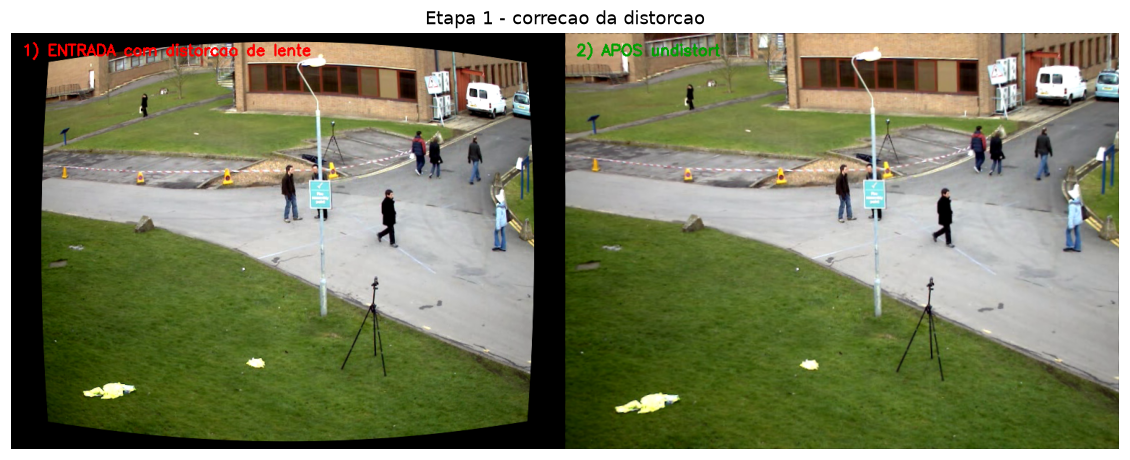

diferença média de intensidade entre entrada e corrigida: 32.1


In [3]:
cap, _tmp = video_capture_u(VIDEO)
cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_DEMO)
ok, frame_original = cap.read()
cap.release()
assert ok, "não foi possível ler o frame do vídeo"

altura, largura = frame_original.shape[:2]
K = reescalar_K(K_calib, tam_calib, (largura, altura))
print(f"frame {FRAME_DEMO}: {largura}x{altura}")
print("K reescalada para a resolução do vídeo:")
print(np.array2string(K, precision=2, suppress_small=True))

# Simulação da lente: aplica a distorção ao frame já retificado.
mapa_x, mapa_y = mapas_distorcao(K, dist, (largura, altura))
frame_distorcido = cv2.remap(frame_original, mapa_x, mapa_y, cv2.INTER_LINEAR,
                             borderMode=cv2.BORDER_CONSTANT)

frame, t_undistort = etapa_undistort(frame_distorcido, K, dist)
print(f"\nundistort: {t_undistort:.2f} ms")

painel = np.hstack([frame_distorcido, frame])
cv2.putText(painel, "1) ENTRADA com distorcao de lente", (15, 30),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
cv2.putText(painel, "2) APOS undistort", (largura + 15, 30),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 160, 0), 2)
mostrar(painel, "Etapa 1 - correcao da distorcao")
imwrite_u(OUT / "ex2b_etapa1_undistort.png", painel)

erro_medio = float(np.mean(cv2.absdiff(frame_distorcido, frame)))
print(f"diferença média de intensidade entre entrada e corrigida: {erro_medio:.1f}")

## Etapa 2 — segmentação da ROI por cor (HSV, TP1)

Alvo: os **cones de sinalização amarelos**, que num veículo autônomo indicam
obra ou desvio. O HSV separa matiz de brilho, então a faixa de cor sobrevive a
mudanças de iluminação — o que não aconteceria em RGB.

Os limites de S e V foram definidos medindo os pixels dos cones neste vídeo.
Mesmo assim, a cor **não basta**: o tijolo do prédio e os caixilhos das janelas
caem na mesma faixa de matiz. Por isso aplicamos dois filtros geométricos que um
robô real também usaria (razão altura/largura e descarte da faixa acima do
horizonte) e reportamos quantas regiões sobrevivem a cada estágio.

HSV + morfologia: 2.08 ms
regiões com área suficiente          : 32
após os filtros geométricos          : 6
taxa de descarte                     : 81%


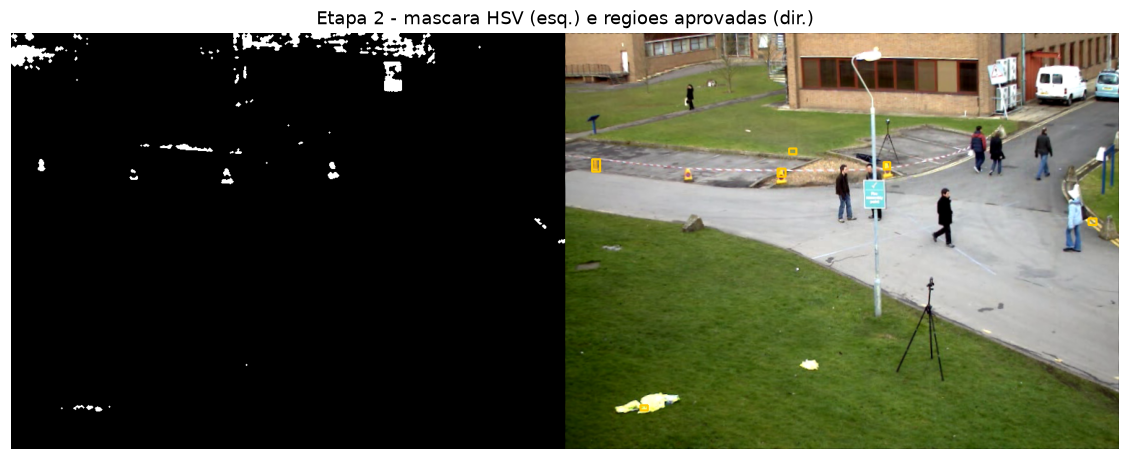


caixas aprovadas (x, y, w, h):
   (37, 174, 11, 17)
   (294, 187, 11, 11)
   (725, 256, 11, 9)
   (441, 178, 9, 10)
   (310, 159, 10, 8)
   (104, 515, 10, 7)


In [4]:
mask, caixas_hsv, t_hsv, diag = etapa_hsv(frame)
print(f"HSV + morfologia: {t_hsv:.2f} ms")
print(f"regiões com área suficiente          : {diag['regioes_brutas']}")
print(f"após os filtros geométricos          : {diag['regioes_filtradas']}")
print(f"taxa de descarte                     : "
      f"{100*(1 - diag['regioes_filtradas']/max(diag['regioes_brutas'],1)):.0f}%")

vis_hsv = frame.copy()
for (x, y, w, h) in caixas_hsv:
    cv2.rectangle(vis_hsv, (x, y), (x + w, y + h), (0, 200, 255), 2)

mostrar(np.hstack([cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR), vis_hsv]),
        "Etapa 2 - mascara HSV (esq.) e regioes aprovadas (dir.)")
imwrite_u(OUT / "ex2b_etapa2_hsv.png",
          np.hstack([cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR), vis_hsv]))

print("\ncaixas aprovadas (x, y, w, h):")
for c in caixas_hsv:
    print("  ", c)

## Etapa 3 — descritores ORB (TP2)

ORB combina o detector FAST com o descritor binário BRIEF, acrescentando
orientação. É o descritor de referência em robótica embarcada: livre de
patente, 32 bytes por ponto e comparação por distância de Hamming, que a CPU
resolve com operações de bit.

Extraímos no quadro inteiro, porque é assim que o descritor serve à odometria
visual e ao fechamento de laço em SLAM, e depois contamos quantos pontos caem
dentro das ROIs das etapas 2 e 4 — um ponto-chave dentro da caixa de um pedestre
é o que permitiria segui-lo por correspondência entre frames.

ORB: 9.78 ms
pontos-chave: 300
descritores : (300, 32) (uint8, 32 bytes/ponto)


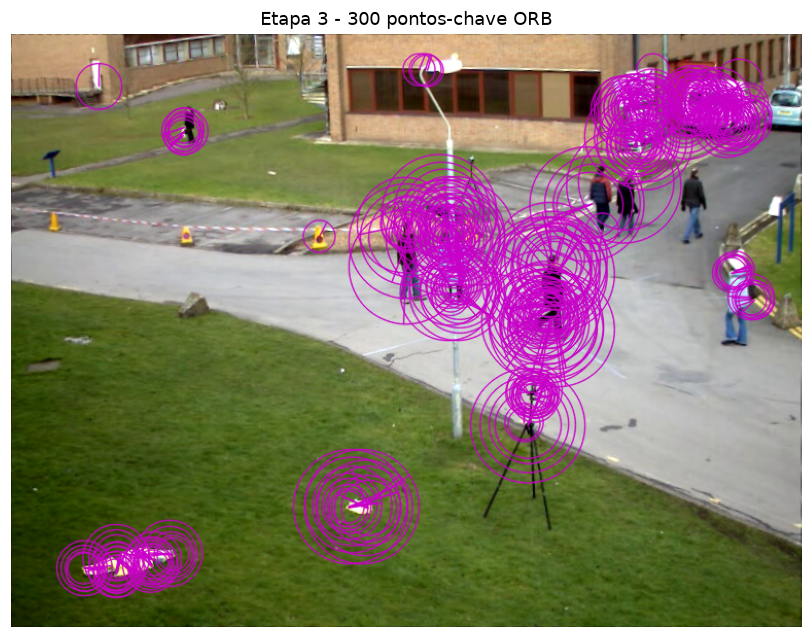


resposta média dos pontos: 0.00271
escalas (octaves) usadas : [0, 1, 2, 3, 4, 5, 6, 7]


In [5]:
kp, des, t_orb = etapa_orb(frame, None)
print(f"ORB: {t_orb:.2f} ms")
print(f"pontos-chave: {len(kp)}")
print(f"descritores : {des.shape if des is not None else 'nenhum'} (uint8, 32 bytes/ponto)")

vis_orb = cv2.drawKeypoints(frame, kp, None, color=(200, 0, 200),
                            flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
mostrar(vis_orb, f"Etapa 3 - {len(kp)} pontos-chave ORB")
imwrite_u(OUT / "ex2b_etapa3_orb.png", vis_orb)

respostas = np.array([p.response for p in kp])
print(f"\nresposta média dos pontos: {respostas.mean():.5f}")
print(f"escalas (octaves) usadas : {sorted(set(p.octave for p in kp))}")

## Etapa 4 — detectores clássicos: HOG+SVM e Haar (TP3)

O **HOG+SVM** descreve a silhueta por histogramas de orientação de gradiente e
classifica com um SVM linear; é o detector de pedestres pré-redes-profundas.
O **Haar Cascade** procura rostos frontais por diferenças de intensidade em
cascata.

Vale observar o resultado do Haar nesta cena: em vídeo de vigilância a
distância, o rosto tem poucos pixels e não está frontal, então o detector não
encontra nada. Isso não é falha de configuração, é o **limite de operação** da
técnica, e é exatamente o motivo pelo qual sistemas reais usam detecção de
corpo inteiro, e não de rosto, para perceber pedestres.

HOG + Haar: 121.83 ms
pessoas detectadas (peso >= 0.30): 4
   HOG0: caixa=(545, 43, 92, 183) peso_svm=0.772
   HOG1: caixa=(661, 162, 85, 169) peso_svm=0.985
   HOG2: caixa=(357, 150, 67, 134) peso_svm=0.603
   HOG3: caixa=(496, 192, 66, 131) peso_svm=1.064
rostos detectados pelo Haar      : 0


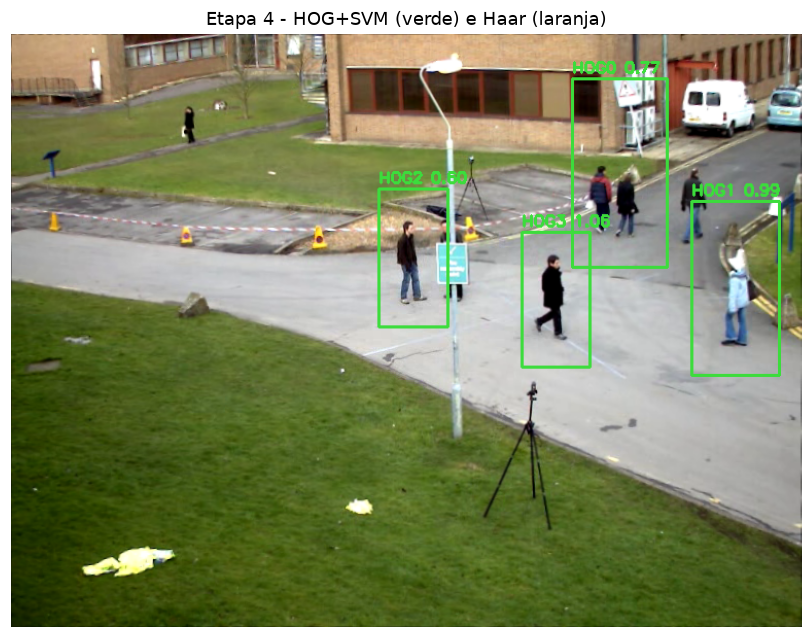

True

In [6]:
pessoas, rostos, t_det = etapa_deteccao(frame, hog, haar)
print(f"HOG + Haar: {t_det:.2f} ms")
print(f"pessoas detectadas (peso >= 0.30): {len(pessoas)}")
for i, (caixa, peso) in enumerate(pessoas):
    print(f"   HOG{i}: caixa={caixa} peso_svm={peso:.3f}")
print(f"rostos detectados pelo Haar      : {len(rostos)}")

vis_det = frame.copy()
for i, ((x, y, w, h), p) in enumerate(pessoas):
    cv2.rectangle(vis_det, (x, y), (x + w, y + h), (60, 220, 60), 2)
    cv2.putText(vis_det, f"HOG{i} {p:.2f}", (x, max(14, y - 6)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (60, 220, 60), 2)
for (x, y, w, h) in rostos:
    cv2.rectangle(vis_det, (x, y), (x + w, y + h), (255, 120, 0), 2)

mostrar(vis_det, "Etapa 4 - HOG+SVM (verde) e Haar (laranja)")
imwrite_u(OUT / "ex2b_etapa4_deteccao.png", vis_det)

## Etapa 5 — classificação das ROIs com MobileNetV2 (OpenCV DNN)

Cada caixa detectada é recortada, redimensionada para 224×224 e classificada
pela mesma rede do item A, agora rodando dentro do pipeline.

**Atenção ao resultado, que é o ponto técnico mais importante deste item.**
As 1000 classes do ImageNet **não incluem "pedestre" nem "cone de sinalização"**.
Ao classificar o recorte de uma pessoa a 40 metros, a rede devolve a classe
visualmente mais próxima do seu vocabulário, com confiança baixa. Não é bug:
é incompatibilidade entre a tarefa (detectar e identificar agentes de trânsito)
e o modelo (classificar objeto único, centralizado, em 1000 categorias
genéricas). A saída correta para esse problema é um detector treinado em COCO,
que possui as classes `person`, `car`, `bicycle` e `traffic light` — exatamente
o que o Exercício 3 faz com YOLO e SSD.

In [7]:
alvos = [(f"HOG{i}", caixa) for i, (caixa, _) in enumerate(pessoas)]
if caixas_hsv:
    alvos.append(("HSV0 (cone)", caixas_hsv[0]))

rotulos, t_cls_total = [], 0.0
for nome, caixa in alvos:
    top3, dt = etapa_classificacao(frame, caixa, net, labels)
    t_cls_total += dt
    if not top3:
        continue
    texto = ", ".join(f"{c} {p*100:.0f}%" for c, p in top3)
    rotulos.append(f"{nome}: {texto}")
    x, y, w, h = caixa
    print(f"{nome:14s} caixa {w:3d}x{h:3d} px -> {texto}")

print(f"\nclassificação de {len(alvos)} ROIs: {t_cls_total:.2f} ms "
      f"({t_cls_total/max(len(alvos),1):.2f} ms por ROI)")

HOG0           caixa  92x183 px -> tricycle 33%, jinrikisha 7%, broom 4%
HOG1           caixa  85x169 px -> broom 24%, tricycle 16%, lawn_mower 10%
HOG2           caixa  67x134 px -> reel 13%, leatherback_turtle 3%, ice_bear 2%
HOG3           caixa  66x131 px -> puck 34%, broom 19%, paddle 11%
HSV0 (cone)    caixa  11x 17 px -> beer_glass 3%, rapeseed 3%, pill_bottle 3%

classificação de 5 ROIs: 65.94 ms (13.19 ms por ROI)


## Resultado final: frame com todas as anotações

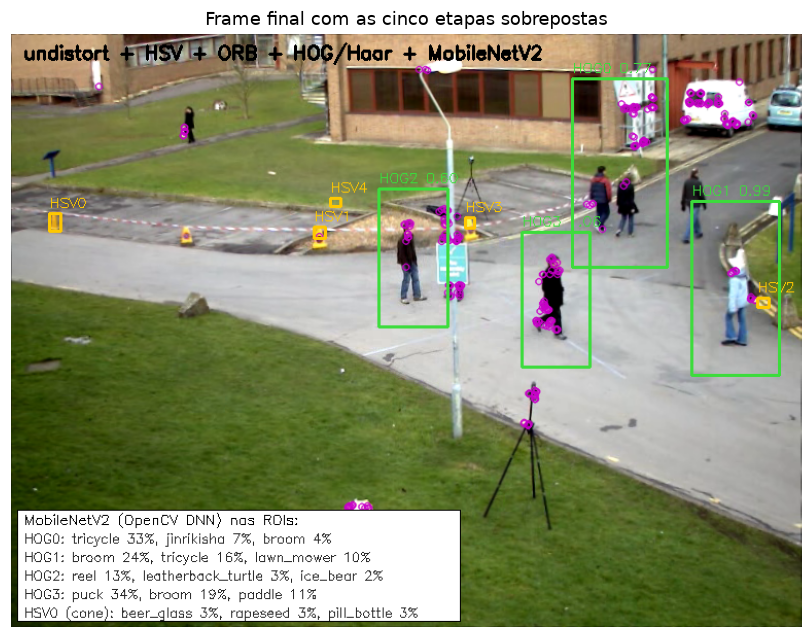

salvo em outputs/ex2b_frame_final.png


In [8]:
final = anotar(frame, caixas_hsv, kp, pessoas, rostos, rotulos)
cv2.putText(final, "undistort + HSV + ORB + HOG/Haar + MobileNetV2",
            (12, 24), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)
mostrar(final, "Frame final com as cinco etapas sobrepostas")
imwrite_u(OUT / "ex2b_frame_final.png", final)
print("salvo em outputs/ex2b_frame_final.png")

## Tempo de cada etapa do pipeline

O enunciado pede o tempo de cada etapa em milissegundos. Abaixo, o frame de
demonstração e, em seguida, a média sobre 30 frames do vídeo — uma única medição
é ruim porque o custo do HOG varia com o conteúdo da cena (quantas janelas da
pirâmide de escalas sobrevivem ao SVM).

In [9]:
tempos_demo = {
    "1_undistort": t_undistort,
    "2_hsv": t_hsv,
    "3_orb": t_orb,
    "4_deteccao": t_det,
    "5_classificacao": t_cls_total,
}
total_demo = sum(tempos_demo.values())

print(tabela(["etapa", "tempo (ms)", "% do total"],
             [[k, f"{v:.2f}", f"{v/total_demo*100:.1f}"]
              for k, v in tempos_demo.items()]
             + [["TOTAL", f"{total_demo:.2f}", "100.0"]],
             titulo=f"Frame {FRAME_DEMO}"))
print(f"\nequivale a {1000/total_demo:.1f} FPS")

Frame 120
+-----------------+------------+------------+
| etapa           | tempo (ms) | % do total |
+-----------------+------------+------------+
| 1_undistort     | 6.06       | 2.9        |
| 2_hsv           | 2.08       | 1.0        |
| 3_orb           | 9.78       | 4.8        |
| 4_deteccao      | 121.83     | 59.2       |
| 5_classificacao | 65.94      | 32.1       |
| TOTAL           | 205.70     | 100.0      |
+-----------------+------------+------------+

equivale a 4.9 FPS


In [10]:
N_FRAMES = 30
cap, _tmp = video_capture_u(VIDEO)
cap.set(cv2.CAP_PROP_POS_FRAMES, 100)

acumulado, contagens = [], []
for i in range(N_FRAMES):
    ok, f_orig = cap.read()
    if not ok:
        break
    f_dist = cv2.remap(f_orig, mapa_x, mapa_y, cv2.INTER_LINEAR,
                       borderMode=cv2.BORDER_CONSTANT)
    r = rodar_pipeline(f_dist, K, dist, net, labels, hog, haar)
    acumulado.append(r["tempos"])
    contagens.append((len(r["caixas_hsv"]), len(r["kp"]),
                      len(r["pessoas"]), len(r["rostos"]),
                      r["kp_em_pessoas"]))
cap.release()

etapas = list(acumulado[0].keys())
medias = {e: float(np.mean([a[e] for a in acumulado])) for e in etapas}
desvios = {e: float(np.std([a[e] for a in acumulado])) for e in etapas}
total = sum(medias.values())

print(tabela(["etapa", "média (ms)", "desvio (ms)", "% do total"],
             [[e, f"{medias[e]:.2f}", f"{desvios[e]:.2f}",
               f"{medias[e]/total*100:.1f}"] for e in etapas]
             + [["TOTAL", f"{total:.2f}", "-", "100.0"]],
             titulo=f"Média sobre {len(acumulado)} frames"))
print(f"\nFPS médio do pipeline completo: {1000/total:.1f}")

c = np.array(contagens)
print(f"\nPor frame (média): {c[:,0].mean():.1f} ROIs de cor, "
      f"{c[:,1].mean():.0f} pontos ORB, {c[:,2].mean():.1f} pessoas (HOG), "
      f"{c[:,3].mean():.1f} rostos (Haar), "
      f"{c[:,4].mean():.1f} pontos ORB dentro das caixas de pessoa")

Média sobre 30 frames
+-----------------+------------+-------------+------------+
| etapa           | média (ms) | desvio (ms) | % do total |
+-----------------+------------+-------------+------------+
| 1_undistort     | 6.55       | 0.48        | 3.6        |
| 2_hsv           | 2.21       | 0.31        | 1.2        |
| 3_orb           | 9.70       | 0.91        | 5.4        |
| 4_deteccao      | 132.08     | 7.71        | 73.3       |
| 5_classificacao | 29.64      | 6.93        | 16.5       |
| TOTAL           | 180.19     | -           | 100.0      |
+-----------------+------------+-------------+------------+

FPS médio do pipeline completo: 5.5

Por frame (média): 6.1 ROIs de cor, 300 pontos ORB, 2.4 pessoas (HOG), 0.0 rostos (Haar), 85.1 pontos ORB dentro das caixas de pessoa


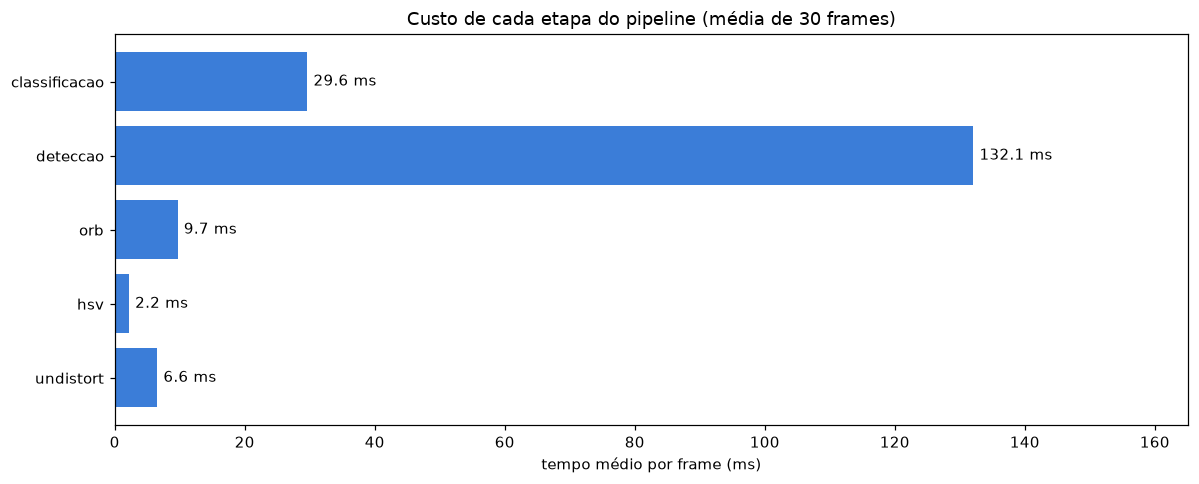

In [11]:
fig, ax = plt.subplots(figsize=(11, 4.5))
nomes = [e.split("_", 1)[1] for e in etapas]
valores = [medias[e] for e in etapas]
barras = ax.barh(nomes, valores, color="#3b7dd8")
ax.bar_label(barras, fmt="%.1f ms", padding=4)
ax.set_xlabel("tempo médio por frame (ms)")
ax.set_title(f"Custo de cada etapa do pipeline (média de {len(acumulado)} frames)")
ax.set_xlim(0, max(valores) * 1.25)
fig.tight_layout()
fig.savefig(OUT / "ex2b_tempos_etapas.png", dpi=120)
plt.show()

## Discussão

**Onde está o gargalo.** A detecção clássica (HOG+SVM) domina o tempo do
pipeline, com folga. O motivo é estrutural: o HOG varre a imagem com uma janela
deslizante em várias escalas, e cada janela exige o cálculo do descritor e uma
avaliação do SVM. As demais etapas são operações de um passe só sobre a imagem
(`undistort`, conversão HSV, morfologia) ou trabalham sobre uma vizinhança
pequena de alguns milhares de pixels (ORB, e a inferência em recortes de
224×224).

**Consequência para hardware embarcado.** Otimizar o pipeline não significa
otimizar tudo: reduzir pela metade o custo do `undistort` muda pouco o FPS,
enquanto trocar o HOG por um detector profundo quantizado, ou restringir a
varredura a uma faixa de interesse da imagem, altera o resultado de forma
significativa. Duas medidas práticas que se apoiam nos números medidos aqui:
processar em resolução reduzida (o custo do HOG cai aproximadamente com a área)
e substituir `cv2.undistort` por `cv2.remap` com mapas pré-calculados, já que os
mapas só dependem da calibração e podem ser computados uma vez na inicialização.

**Limitação de cada técnica, evidenciada pelos números.**
A segmentação por cor descartou cerca de 80% das regiões candidatas por
critérios geométricos: sem conhecimento externo da cena, a cor sozinha confunde
tijolo com cone. O Haar não encontrou nenhum rosto, porque a resolução do rosto
nesta cena está abaixo do seu limite. E o classificador ImageNet, aplicado a
recortes de pedestres, devolve classes sem relação com trânsito, porque seu
vocabulário não contém a categoria procurada.

**O que isso motiva.** Cada limitação acima aponta para a etapa seguinte do AT:
detectores treinados em COCO com as classes de trânsito (Exercício 3) e
segmentação semântica aprendida, que classifica cada pixel em vez de depender de
faixas de cor definidas à mão (Exercício 4).